In [2]:
pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
from mlxtend.plotting import plot_decision_regions
import pandas as pd

In [5]:
df = pd.DataFrame()
     

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [6]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

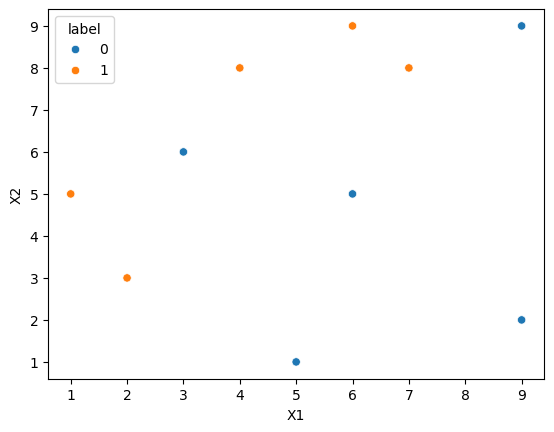

In [7]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [8]:
df['Weights'] = 1/df.shape[0]

In [9]:
df

,X1,X2,label,Weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [16]:
dt = DecisionTreeClassifier(max_depth=1)

dt.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [17]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

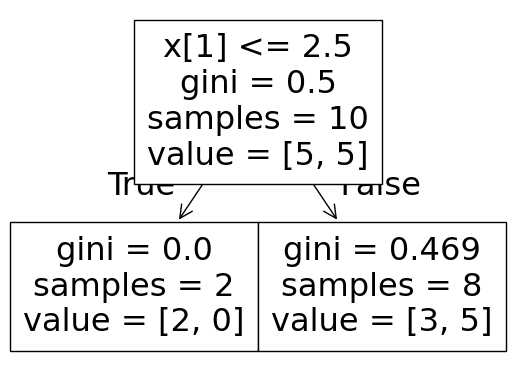

In [18]:
plot_tree(dt)

<Axes: >

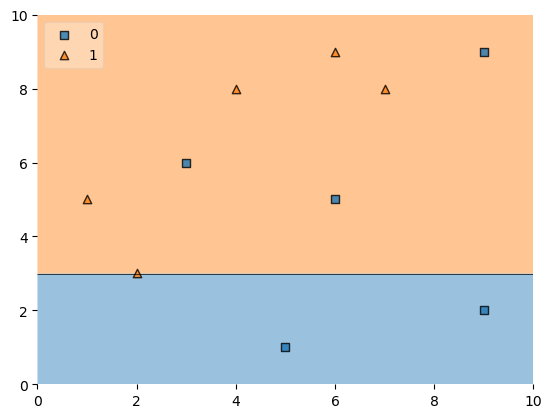

In [19]:
plot_decision_regions(X,y,clf=dt,legend=2)

In [20]:
df['y_pred'] = dt.predict(X)

In [21]:
df

,X1,X2,label,Weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [22]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error)

In [23]:
alpha1 = calculate_model_weight(0.3)
alpha1


0.42364893019360184

In [28]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['Weights'] * np.exp(-alpha)
  else:
    return row['Weights'] * np.exp(alpha)

In [29]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [30]:
df

,X1,X2,label,Weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [31]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
     

In [32]:
df

,X1,X2,label,Weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [33]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])


In [34]:
df

,X1,X2,label,Weights,y_pred,updated_weights,nomalized_weights,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.166559,0.309508
3,4,8,1,0.1,1,0.065508,0.071475,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.452458
5,6,9,1,0.1,1,0.065508,0.071475,0.523933
6,6,5,0,0.1,1,0.152653,0.166559,0.690492
7,7,8,1,0.1,1,0.065508,0.071475,0.761967
8,9,9,0,0.1,1,0.152653,0.166559,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,1.000000


In [35]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [36]:
df

,X1,X2,label,Weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [37]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices
     

In [38]:
index_values = create_new_dataset(df)

index_values

[3, 5, 0, 9, 2, 4, 8, 3, 5, 2]

In [39]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [40]:
second_df

,X1,X2,label,Weights
3,4,8,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
9,9,2,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1
8,9,9,0,0.1
3,4,8,1,0.1
5,6,9,1,0.1
2,3,6,0,0.1


In [41]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [42]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values


In [43]:

dt2 = DecisionTreeClassifier(max_depth=1)

In [44]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

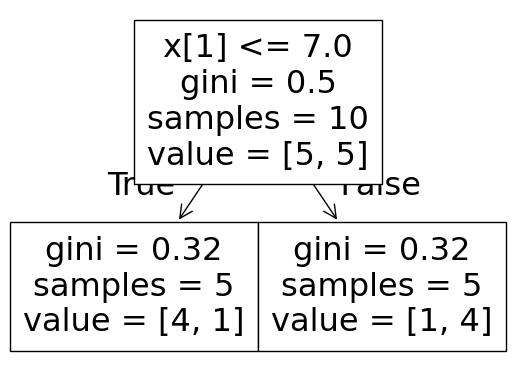

In [45]:
plot_tree(dt2)

<Axes: >

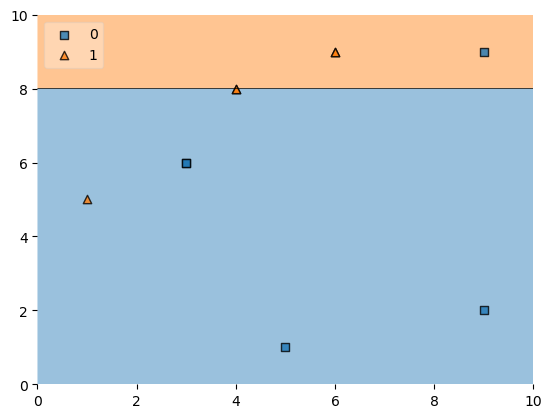

In [46]:

plot_decision_regions(X, y, clf=dt2, legend=2)

In [47]:
second_df['y_pred'] = dt2.predict(X)

In [48]:


second_df

,X1,X2,label,Weights,y_pred
3,4,8,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,0
9,9,2,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0
8,9,9,0,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,1
2,3,6,0,0.1,0


In [50]:

alpha2 = calculate_model_weight(0.2)

In [51]:
alpha2

0.6931471805599453

In [52]:
def update_row_weights(row,alpha=.6931471805599453):
  if row['label'] == row['y_pred']:
    return row['Weights'] * np.exp(-alpha)
  else:
    return row['Weights'] * np.exp(alpha)

In [53]:


second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [54]:
second_df

,X1,X2,label,Weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.05
5,6,9,1,0.1,1,0.05
0,1,5,1,0.1,0,0.20
9,9,2,0,0.1,0,0.05
2,3,6,0,0.1,0,0.05
4,5,1,0,0.1,0,0.05
8,9,9,0,0.1,1,0.20
3,4,8,1,0.1,1,0.05
5,6,9,1,0.1,1,0.05
2,3,6,0,0.1,0,0.05


In [55]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
     

In [56]:
second_df

,X1,X2,label,Weights,y_pred,updated_weights,nomalized_weights
3,4,8,1,0.1,1,0.05,0.0625
5,6,9,1,0.1,1,0.05,0.0625
0,1,5,1,0.1,0,0.20,0.2500
9,9,2,0,0.1,0,0.05,0.0625
2,3,6,0,0.1,0,0.05,0.0625
4,5,1,0,0.1,0,0.05,0.0625
8,9,9,0,0.1,1,0.20,0.2500
3,4,8,1,0.1,1,0.05,0.0625
5,6,9,1,0.1,1,0.05,0.0625
2,3,6,0,0.1,0,0.05,0.0625


In [57]:

second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [58]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
     

In [59]:
index_values = create_new_dataset(second_df)

In [61]:
query = np.array([1,5]).reshape(1,2)
dt.predict(query)

array([1])

In [62]:
dt2.predict(query)


array([0])

In [64]:
np.sign(alpha1*1 + alpha2*(-1))

-1.0